# PINNs vs Data Driven Neural Networks for Fluid Flow

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from dataclasses import dataclass
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator


### Objective
Evaluate whether incorporating physical constraints improves prediction accuracy when training data are sparse.

## Governing Equation (Fluid Flow)
I am going to use the simplified 1D flow equation instead of full Navier-Stokes.

A practical choice is the advection-diffusion equation: https://en.wikipedia.org/wiki/Convection%E2%80%93diffusion_equation. 

$$
\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x}
= D \frac{\partial^2 u}{\partial x^2}
$$

Meaning of each term
- $u(x,t)$: transported scalar field (e.g., pollutant concentration, chlorine level, temperature)

- $c$: advection velocity (flow speed of the water)

- $D$: diffusion coefficient (mixing/dispersion)

- $\frac{\partial u}{\partial t}$: rate of change of concentration over time

- $c \frac{\partial u}{\partial x}$: transport due to bulk flow of the fluid

- $D \frac{\partial^2 u}{\partial x^2}$: spreading due to diffusion or turbulent mixing

## Two Models to Compare

### Model 1 - Standard Neural Network 
Train a neural network to learn,
$u(x, t) = NN(x, t)$, 
using only data points. 

Loss:

$\frac{1}{N} \sum({u_{pred} - u_{data}})^2$


### Model 2 - Physics Informed Neural Network
Use the same network,
$u(x, t) = NN(x, t)$,
but include the physics into the loss function.

Physics Loss:

$f(x, t) = \frac{du}{dt} + c \frac{du}{dx} - D \frac{du^2}{d^2x}$

$L_{physics} = \frac{1}{N_f} \sum_{i=1}^{N_f}{|f(x_i, t_i)|^2}$

$L = L_{data} + \lambda \times L_{physics}$, where lambda is a weighting parameter to control how much the physics constrains the system. 

## Initial and boundary conditions

For my initial condition I am going to use Gausian Pulse:

$u(x, 0) = e^{-50(x-0.5)^2}$

This can represent a localised pollutant spill at the centre of the river, diffusion spreads the plume, and advection moves it downstream. 

The advantages of this are: that it is a smooth function, produces easily interpretable results, widely used in transport modelling.

## Exact Solution 

$$
u(x,t) = \frac{1}{\sqrt{1+200 D t}} e^{- \frac{50(x-ct-0.5)^2}{1+200 D t}}
$$



## Define a standard fully-connected network in PyTorch

In [4]:

def exact_solution(c, D, x, t):
    """
    Analytical solution of the 1D advection–diffusion equation
    with Gaussian initial condition.
    """

    denom = 1 + 200*D*t
    prefactor = 1 / torch.sqrt(denom)

    exp_term = torch.exp(-50*(x - c*t - 0.5)**2 / denom)

    u = prefactor * exp_term

    return u

def initial_condition(x, c, D):
    """
    Gaussian initial condition for 1D advection–diffusion equation
    x: tensor of spatial points
    Returns u(x,0)
    """
    t0 = torch.zeros_like(x)  # t = 0
    u0 = exact_solution(c, D, x, t0)  # evaluate the exact solution at t=0
    return u0

def relative_l2_error(u_pred, u_true):
    return torch.norm(u_pred - u_true) / torch.norm(u_true)

class FCN(nn.Module):
    "Defines a standard fully-connected network in PyTorch"

    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

## Loading and Saving Model 

In [5]:
def save_pinn_checkpoint(model, optimiser, data, pde_params, num_epochs, filename="new.pth"):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimiser.state_dict(),
        "data": data,
        "pde_params": pde_params,
        "num_epochs": num_epochs
    }
    
    torch.save(checkpoint, filename)
    print(f"Checkpoint saved to {filename}")


def load_pinn_checkpoint(model_class, model_args, filename="pinn_full_checkpoint.pth"):
    checkpoint = torch.load(filename)

    # Recreate model architecture
    model = model_class(*model_args)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()  # set to evaluation mode

    # Recreate optimizer (you can change lr if needed)
    optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
    optimiser.load_state_dict(checkpoint["optimizer_state_dict"])

    data = checkpoint["data"]
    pde_params = checkpoint["pde_params"]
    num_epochs = checkpoint["num_epochs"]

    return model, optimiser, data, pde_params, num_epochs

## Plotting Functions

In [6]:

def smooth(y, window=200):
    y = np.array(y)
    return np.convolve(y, np.ones(window)/window, mode="valid")

def plot_exact_solution(data):

    plt.figure(figsize=(6,4))

    plt.contourf(
        data.X_test,
        data.T_test,
        data.u_true,
        levels=50,
        cmap="viridis"
    )

    plt.xlabel("x")
    plt.ylabel("t")
    plt.title("Exact solution")

    plt.colorbar(label="u(x,t)")
    plt.show()
    
def plot_pinn_losses(L_data, L_phys, L_ic, window=None):

    plt.figure(figsize=(6,4))

    if window:
        L_data = smooth(L_data, window)
        L_phys = smooth(L_phys, window)
        L_ic = smooth(L_ic, window)

    plt.plot(L_data, label="Data loss")
    plt.plot(L_phys, label="Physics loss")
    plt.plot(L_ic, label="IC loss")

    plt.yscale("log")

    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training losses")

    plt.legend()
    plt.show()
    
def plot_nn_losses(L_data, window=None):

    plt.figure(figsize=(6,4))

    if window:
        L_data = smooth(L_data, window)

    plt.plot(L_data, label="Data loss")

    plt.yscale("log")

    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training losses")

    plt.legend()
    plt.show()
    

def plot_error_history(error_history, window=None):

    plt.figure(figsize=(6,4))

    if window:
        error_history = smooth(error_history, window)

    plt.plot(error_history)

    plt.yscale("log")

    plt.xlabel("Iteration")
    plt.ylabel("Relative L2 error")
    plt.title("Prediction error during training")

    plt.show()
    
def compute_pde_residual(data, model, c, D):

    X = data.X_test_flat.clone().requires_grad_(True)

    u = model(X)

    grads = torch.autograd.grad(
        u, X,
        torch.ones_like(u),
        create_graph=True
    )[0]

    dudx = grads[:,0:1]
    dudt = grads[:,1:2]

    d2udx2 = torch.autograd.grad(
        dudx, X,
        torch.ones_like(dudx),
        create_graph=True
    )[0][:,0:1]

    f = dudt + c*dudx - D*d2udx2

    nx, nt = data.X_test.shape
    f = f.detach().reshape(nx, nt)

    return torch.abs(f)
    
def plot_pde_residual(data, residual, res_limit=None):
    
    residual = residual.numpy()  # assuming residual is a torch tensor
    
    norm = LogNorm(vmin=1e-6, vmax=res_limit)
    
    levels = np.logspace(np.log10(1e-6), np.log10(res_limit), 100)
    
    plt.figure(figsize=(6, 4))
    
    # contourf returns a QuadContourSet, needed for colorbar
    cf = plt.contourf(
        data.X_test,
        data.T_test,
        np.abs(residual),
        cmap="magma",
        levels=levels,
        norm=norm
    )

    plt.xlabel("x")
    plt.ylabel("t")
    plt.title("Log PDE residual")
    
    # pass the mappable object cf to colorbar
    plt.colorbar(cf, label="log10 |f(x,t)|", ticks=LogLocator(base=10.00).tick_values(1e-6, res_limit))
    
    plt.show()
    
def plot_losses_and_error(error_history, L_data, L_phys=None, L_ic=None, loss_range=None, window=None):
    plt.figure(figsize=(12,5))

    # Subplot 1: Losses
    plt.subplot(1, 2, 1)
    L_data_plot = smooth(L_data, window) if window else L_data
    plt.plot(L_data_plot, label="Data loss")

    if L_phys is not None:
        L_phys_plot = smooth(L_phys, window) if window else L_phys
        plt.plot(L_phys_plot, label="Physics loss")
    if L_ic is not None:
        L_ic_plot = smooth(L_ic, window) if window else L_ic
        plt.plot(L_ic_plot, label="IC loss")

    plt.yscale("log")
    
    print(loss_range)
    
    if loss_range:
        plt.ylim(loss_range[0], loss_range[1])
        
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Losses")
    plt.legend()

    # Subplot 2: Error
    plt.subplot(1, 2, 2)
    error_plot = smooth(error_history, window) if window else error_history
    plt.plot(error_plot)
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Relative L2 Error")
    plt.title("Prediction Error During Training")

    plt.tight_layout()
    plt.show()

## Generate Observation Data

Advection velocity c: 1.0
Diffusion coefficient D: 0.01


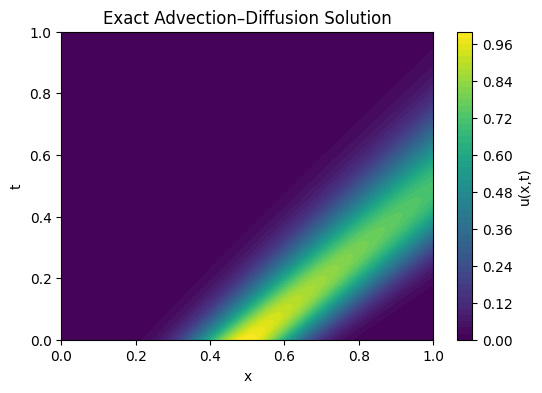

In [7]:
torch.manual_seed(123)

# physical parameters
c = 1.0
D = 0.01

print(f"Advection velocity c: {c}")
print(f"Diffusion coefficient D: {D}")


# --------------------------------------
# test grid (ground truth)
# --------------------------------------

x_test = torch.linspace(0,1,100)
t_test = torch.linspace(0,1,100)

X_test, T_test = torch.meshgrid(x_test, t_test, indexing="ij")

u_exact = exact_solution(c, D, X_test, T_test)

plt.figure(figsize=(6,4))
plt.contourf(X_test, T_test, u_exact, levels=50)
plt.xlabel("x")
plt.ylabel("t")
plt.title("Exact Advection–Diffusion Solution")
plt.colorbar(label="u(x,t)")
plt.show()


# Track Error
X_eval = torch.cat([X_test.reshape(-1,1), T_test.reshape(-1,1)], dim=1)
u_true = exact_solution(c, D, X_eval[:,0:1], X_eval[:,1:2])
u_true = u_true.reshape(100,100)


## Define Data Classes

In [8]:
@dataclass
class NNData:

    # evaluation grid
    X_test: torch.Tensor
    T_test: torch.Tensor
    u_true: torch.Tensor
    X_test_flat: torch.Tensor

    # supervised observations
    X_obs: torch.Tensor
    u_obs: torch.Tensor
    
    # loss history
    L_data: list
    
    # error history
    error: list
    
    
@dataclass
class PINNData:
    # evaluation grid
    X_test: torch.Tensor
    T_test: torch.Tensor
    u_true: torch.Tensor
    X_test_flat: torch.Tensor

    # supervised observations
    X_obs: torch.Tensor
    u_obs: torch.Tensor

    # collocation points
    N_physics: int

    # initial condition
    X_ic: torch.Tensor
    u_ic: torch.Tensor
    
    # loss history
    L_data: list
    L_phys: list
    L_ic: list
    
    # error history
    error: list
    
    def sample_physics(self):
        x = torch.rand(self.N_physics, 1, requires_grad=True)
        t = torch.rand(self.N_physics, 1, requires_grad=True)
        return torch.cat([x, t], dim=1)
    
@dataclass
class PDEConfig:
    c: float
    D: float

## Loss Functions

In [9]:
# Loss

def data_loss(model, X_obs, u_obs):
    u_pred = model(X_obs)
    return torch.mean((u_pred - u_obs) ** 2)

def physics_loss(model, X_physics, pde):
    u = model(X_physics)

    grads = torch.autograd.grad(
        u,
        X_physics,
        torch.ones_like(u),
        create_graph=True
    )[0]

    dudx = grads[:,0:1]
    dudt = grads[:,1:2]

    d2udx2 = torch.autograd.grad(
        dudx,
        X_physics,
        torch.ones_like(dudx),
        create_graph=True
    )[0][:,0:1]

    f = dudt + pde.c * dudx - pde.D * d2udx2

    return torch.mean(f**2)

def ic_loss(model, X_ic, u_ic):
    u_pred = model(X_ic)
    return torch.mean((u_pred - u_ic) ** 2)

In [10]:
def pinn_loss(data, model, log, pde, lambdas):
    lambda_data, lambda_phys, lambda_ic = lambdas

    L_data = data_loss(model, data.X_obs, data.u_obs)

    L_phys = physics_loss(
        model,
        data.sample_physics(),
        pde
    )

    L_ic = ic_loss(
        model,
        data.X_ic,
        data.u_ic
    )

    if log:
        # print(
        #     f"L_data={L_data.item():.2e}",
        #     f"L_phys={L_phys.item():.2e}",
        #     f"L_ic={L_ic.item():.2e}"
        # )
        
        data.L_data.append(L_data.item())    
        data.L_phys.append(L_phys.item())    
        data.L_ic.append(L_ic.item())    

    return lambda_data * L_data + lambda_phys * L_phys + lambda_ic * L_ic


def nn_loss(data, model, log, *_):
    u_pred = model(data.X_obs)
    L_data = torch.mean((u_pred - data.u_obs) ** 2)
    
    if log:
        # print(f"L_data={L_data.item():.2e}")
        data.L_data.append(L_data.item())    

    return L_data

## Evaluation Function

In [11]:
def evaluate(step, data, model):
    u_pred = model(data.X_test_flat).detach().reshape(100,100)
    error = relative_l2_error(u_pred, data.u_true)

    print(f"Step {step} | Relative L2 Error: {error.item():.4e}")

    plt.figure(figsize=(6,4))

    plt.contourf(
        data.X_test,
        data.T_test,
        u_pred,
        levels=50,
        cmap="viridis"
    )

    plt.xlabel("x")
    plt.ylabel("t")

    plt.title(
        f"NN solution at step {step}\n"
        f"Rel L2 error = {error.item():.2e}"
    )

    plt.colorbar(label="u(x,t)")
    plt.show()

## Training Function

In [12]:
def train(
    model,
    data,
    optimiser,
    loss_fn,
    num_epochs,
    pde=None,
    lambdas=None,
    save_filename="pinn_checkpoint.pth"
):
    for step in range(num_epochs):
        log = True 

        optimiser.zero_grad()

        loss = loss_fn(data, model, log, pde, lambdas)

        loss.backward()
        optimiser.step()

        if log:
            u_pred = model(data.X_test_flat).detach().reshape(100,100)
            error = relative_l2_error(u_pred, data.u_true)
            data.error.append(error.item())
            # np.abs(u_pred - u_true)
            
        if step % 5000 == 0:
            evaluate(step, data, model)

    # Save checkpoint after training
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimiser.state_dict(),
        "data": data,
        "pde_params": pde,
        "num_epochs": num_epochs
    }
    torch.save(checkpoint, save_filename)
    print(f"Training finished. Checkpoint saved to {save_filename}")

## Standard Neural Network

In [13]:
nn_model = FCN(2,1,32,3)

#### Obersvation Data

In [14]:
N_obs = 200 # 200 - 500

x_obs = torch.rand(N_obs,1)
t_obs = torch.rand(N_obs,1)
u_obs = exact_solution(c, D, x_obs, t_obs) + 0.02*torch.randn_like(x_obs)

X_obs = torch.cat([x_obs, t_obs], dim=1).requires_grad_(True)

#### Evaluation Grid

In [15]:
X_eval = torch.cat(
    [X_test.reshape(-1,1), T_test.reshape(-1,1)],
    dim=1
)

u_true = exact_solution(
    c, 
    D, 
    X_eval[:,0:1], 
    X_eval[:,1:2]
).reshape(100,100)

#### Create Dataset

In [16]:
nn_data = NNData(
    X_test=X_test,
    T_test=T_test,
    u_true=u_true,
    X_test_flat=X_eval,

    X_obs=X_obs,
    u_obs=u_obs,
    
    L_data=[],
    
    error=[]
)

#### Optimiser 

In [17]:
optimiser = torch.optim.Adam(
    nn_model.parameters(),
    lr=1e-3
)

#### PDE Configuration

In [18]:
pde = PDEConfig(
    c=1.0,
    D=0.01
)

#### Train

Step 0 | Relative L2 Error: 1.0601e+00


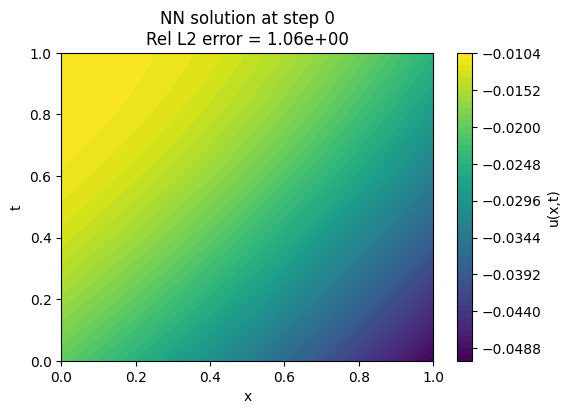

Step 5000 | Relative L2 Error: 2.4249e-02


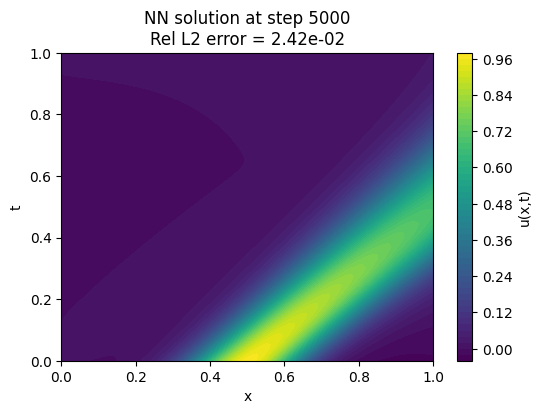

Step 10000 | Relative L2 Error: 2.8473e-02


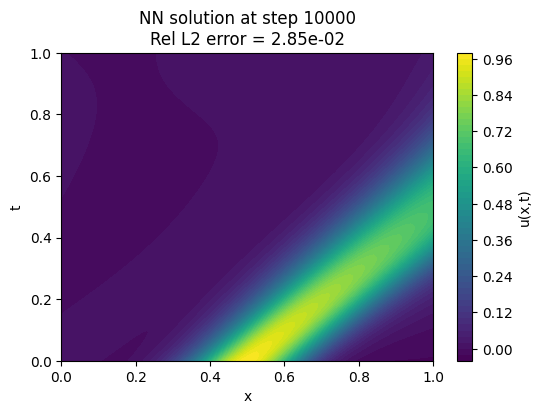

Step 15000 | Relative L2 Error: 4.1040e-02


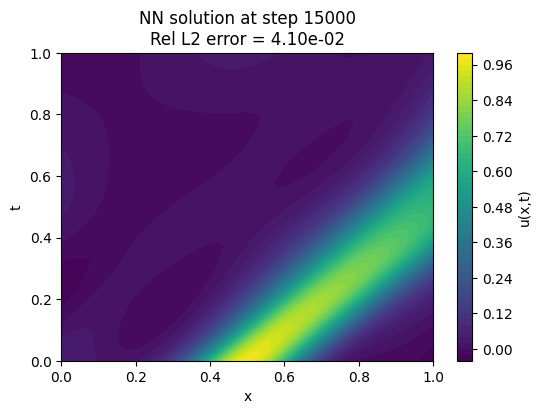

Training finished. Checkpoint saved to nn_full_checkpoint.pth


In [19]:
num_epochs = 15001

train(
    model=nn_model,
    data=nn_data,
    optimiser=optimiser,
    loss_fn=nn_loss,
    num_epochs=num_epochs,
    pde=pde,
    save_filename="nn_full_checkpoint.pth"
)

### After Training

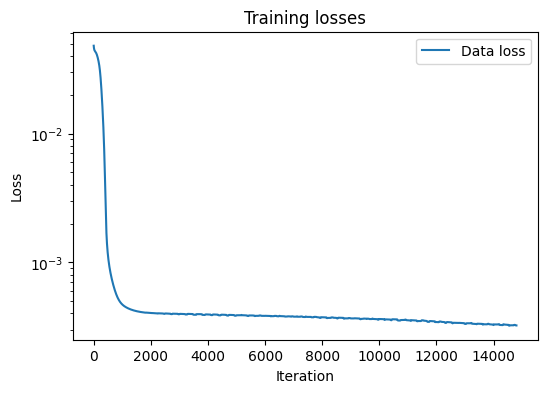

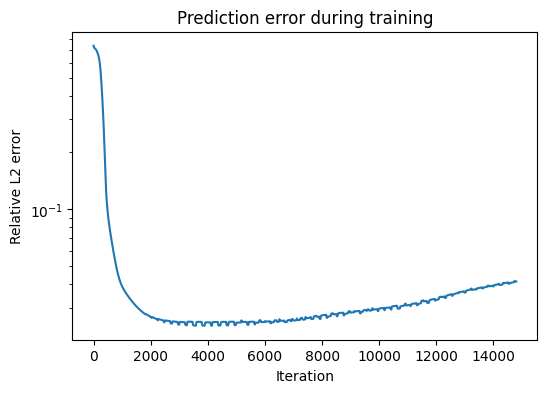

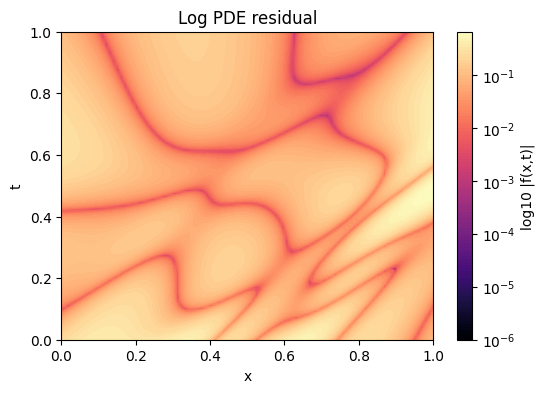

In [20]:
plot_nn_losses(nn_data.L_data, window=200)
plot_error_history(nn_data.error, window=200)

res_nn = compute_pde_residual(nn_data, nn_model, c, D)
res_limit = res_nn.max().item()

plot_pde_residual(nn_data, res_nn, res_limit)

## Physics Informed Neural Network

In [21]:
# define a neural network to train
pinn_model = FCN(2,1,32,3)

#### Observation Data

In [22]:
N_obs = 20 # 20 - 50

x_obs = torch.rand(N_obs,1)
t_obs = torch.rand(N_obs,1)
u_obs = exact_solution(c, D, x_obs, t_obs) + 0.02*torch.randn_like(x_obs)

X_obs = torch.cat([x_obs, t_obs], dim=1).requires_grad_(True)

#### Physics Points

In [23]:
N_physics =  2000 # 1000 - 10,000

#### Inital Condition Points

In [24]:
N_ic = 100 # 100 - 200

x_ic = torch.rand(N_ic, 1)
X_ic = torch.cat([x_ic, torch.zeros_like(x_ic)], dim=1)  # t=0
u_ic_target = initial_condition(x_ic, c, D)  # target values at t=0

#### Evaluation Grid

In [25]:
X_eval = torch.cat(
    [X_test.reshape(-1,1), T_test.reshape(-1,1)],
    dim=1
)

u_true = exact_solution(
    c, 
    D, 
    X_eval[:,0:1], 
    X_eval[:,1:2]
).reshape(100,100)


#### Create Dataset

In [26]:
pinn_data = PINNData(
    X_test=X_test,
    T_test=T_test,
    u_true=u_true,

    X_test_flat=X_eval,

    X_obs=X_obs,
    u_obs=u_obs,

    N_physics=N_physics,

    X_ic=X_ic,
    u_ic=u_ic_target,
    
    L_data=[],
    L_phys=[],
    L_ic=[],
    
    error=[]
)

#### Optimiser 

In [27]:
optimiser = torch.optim.Adam(
    pinn_model.parameters(),
    lr=1e-3
)

#### PDE Configuration

In [28]:
pde = PDEConfig(
    c=1.0,
    D=0.01
)

### Train

Step 0 | Relative L2 Error: 8.9539e-01


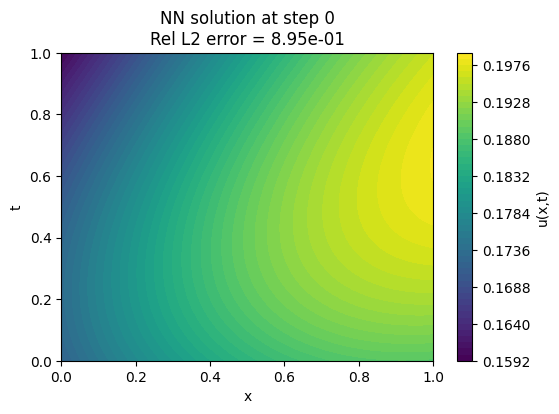

Step 5000 | Relative L2 Error: 8.3208e-02


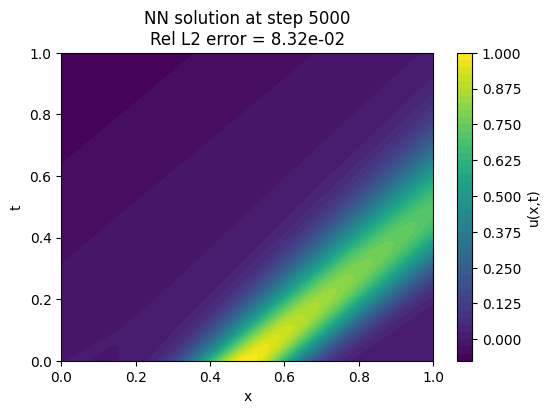

Step 10000 | Relative L2 Error: 5.9662e-02


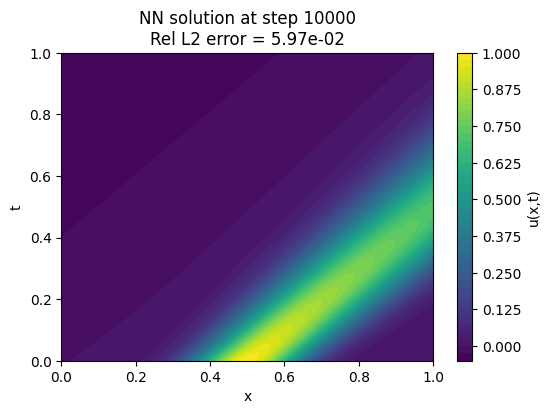

Step 15000 | Relative L2 Error: 5.8597e-02


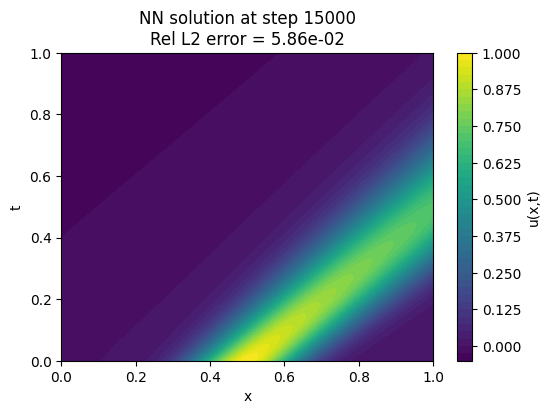

Training finished. Checkpoint saved to pinn_full_checkpoint.pth


In [29]:
num_epochs = 15001

train(
    model=pinn_model,
    data=pinn_data,
    optimiser=optimiser,
    loss_fn=pinn_loss,
    num_epochs=num_epochs,
    pde=pde,
    lambdas=[1e2, 5e3, 1e4], # [lambda_data, lambda_phys, lambda_ic] 
    save_filename="pinn_full_checkpoint.pth"
)

### After Training

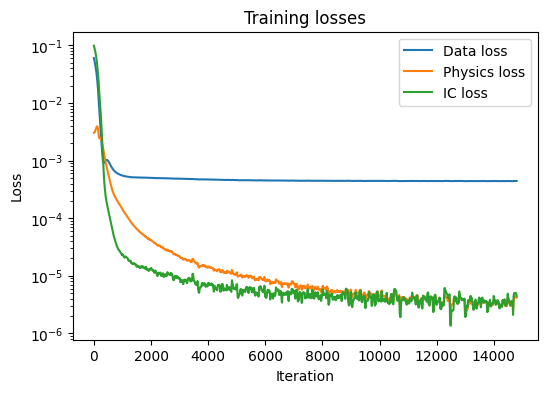

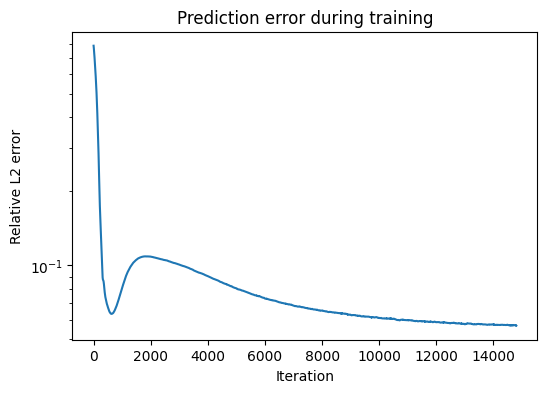

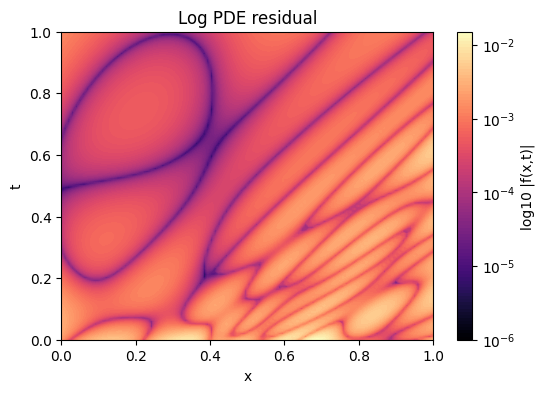

In [30]:
plot_pinn_losses(pinn_data.L_data, pinn_data.L_phys, pinn_data.L_ic, window=200)
plot_error_history(pinn_data.error, window=200)

res_pinn = compute_pde_residual(pinn_data, pinn_model, c, D)
res_limit = res_pinn.max().item()
plot_pde_residual(pinn_data, res_pinn, res_limit)

## Test Generalisation  

### Code

In [47]:
def test_generalization(model, data, pde_params, residual=None, test_points=100, sol_limit=None, err_limit=None, res_limit=None):
    """
    Evaluate PINN generalization on unseen points.

    Args:
        model: trained PINN model
        data: instance of PINNData or NNData
        pde_params: instance of PDEConfig (with attributes .c and .D)
        test_points: number of points per axis for the test grid
    """
    c = pde_params.c
    D = pde_params.D

    # Convert tensors to numpy for linspace
    x_min, x_max = data.X_test.min().item(), data.X_test.max().item()
    t_min, t_max = data.T_test.min().item(), data.T_test.max().item()

    # Create test grid
    x = np.linspace(x_min, x_max, test_points)
    t = np.linspace(t_min, t_max, test_points)
    X_grid, T_grid = np.meshgrid(x, t, indexing="ij")
    X_test_flat = torch.tensor(np.column_stack([X_grid.ravel(), T_grid.ravel()]), dtype=torch.float32)

    # Model predictions
    with torch.no_grad():
        u_pred = model(X_test_flat).numpy().reshape(test_points, test_points)

    # Relative L2 error
    u_true = data.u_true.numpy().reshape(test_points, test_points)
    rel_l2_error = np.linalg.norm(u_pred - u_true) / np.linalg.norm(u_true)
    print(f"Relative L2 error on test grid: {rel_l2_error:.5e}")

    plt.figure(figsize=(18,5))

    # Plot predicted vs exact
    ticks_sol = np.linspace(-0.1, 1.00, int(round((sol_limit+0.1)*10)))
    levels_sol = np.linspace(-1e-1, sol_limit, 100)
    
    ticks_err = LogLocator(base=10.00).tick_values(err_limit[0], err_limit[1])
    levels_err = np.logspace(np.log10(err_limit[0]), np.log10(err_limit[1]), 100)  # 100 levels
    
    # Exact solution
    ax1 = plt.subplot(1,3,1)
    cf1 = ax1.contourf(X_grid, T_grid, u_true, levels=levels_sol, cmap='viridis')
    plt.colorbar(cf1, label='u_true(x,t)', ticks=ticks_sol)
    ax1.set_title("Exact solution")
    ax1.set_aspect('equal')  
    
    plt.xlabel("x")
    plt.ylabel("t")

    # Model Prediction
    ax2 = plt.subplot(1,3,2)
    cf2 = ax2.contourf(X_grid, T_grid, u_pred, levels=levels_sol, cmap='viridis')
    plt.colorbar(cf2, label='u_pred(x,t)', ticks=ticks_sol)
    ax2.set_title("Model Prediction")
    ax2.set_aspect('equal') 

    plt.xlabel("x")
    plt.ylabel("t")

    # Prediction error
    ax3 = plt.subplot(1,3,3)
    cf3 = ax3.contourf(
        X_grid, T_grid, np.abs(u_pred - u_true)/np.max(np.abs(u_true)),
        levels=levels_err, cmap='magma', norm=colors.LogNorm()
    )
    plt.colorbar(cf3, label='|error|', ticks=ticks_err)
    ax3.set_title("Prediction error")
    ax3.set_aspect('equal') 

    # Scatter original test points
    ax3.scatter(
        data.X_obs[:,0].detach().numpy(),  # x-coordinates
        data.X_obs[:,1].detach().numpy(),  # t-coordinates
        color='cyan', s=20, label='Obs points', edgecolors='k', alpha=0.8
    )

    plt.xlabel("x")
    plt.ylabel("t")

    plt.subplots_adjust(wspace=0.4)
    plt.show()

    # Compute PDE residual on test grid
    plot_pde_residual(data, residual, res_limit)

    avg_residual = torch.sqrt(torch.sum(residual**2) / residual.numel())
    print(f"Average PDE residual on test grid: {avg_residual:.5e}")

### Load Model

In [32]:
with torch.serialization.safe_globals([NNData, PDEConfig]):
    nn_checkpoint = torch.load("nn_full_checkpoint.pth", weights_only=False)
    
loaded_nn_model = FCN(2, 1, 32, 3)
loaded_nn_model.load_state_dict(nn_checkpoint["model_state_dict"])
loaded_nn_model.eval()

loaded_nn_data = nn_checkpoint["data"]      # now safe
loaded_nn_pde = nn_checkpoint["pde_params"]

In [33]:
with torch.serialization.safe_globals([PINNData, PDEConfig]):
    pinn_checkpoint = torch.load("pinn_full_checkpoint.pth", weights_only=False)
    
loaded_pinn_model = FCN(2, 1, 32, 3)
loaded_pinn_model.load_state_dict(pinn_checkpoint["model_state_dict"])
loaded_pinn_model.eval()

loaded_pinn_data = pinn_checkpoint["data"]      # now safe
loaded_pinn_pde  = pinn_checkpoint["pde_params"]

### Output

[1.587795708246631e-07, 1]


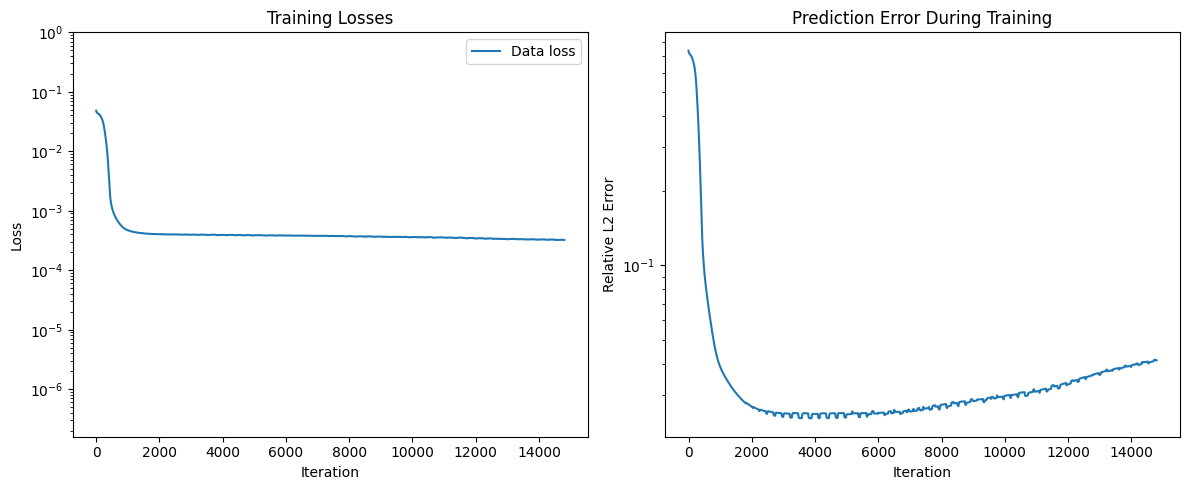

[1.587795708246631e-07, 1]


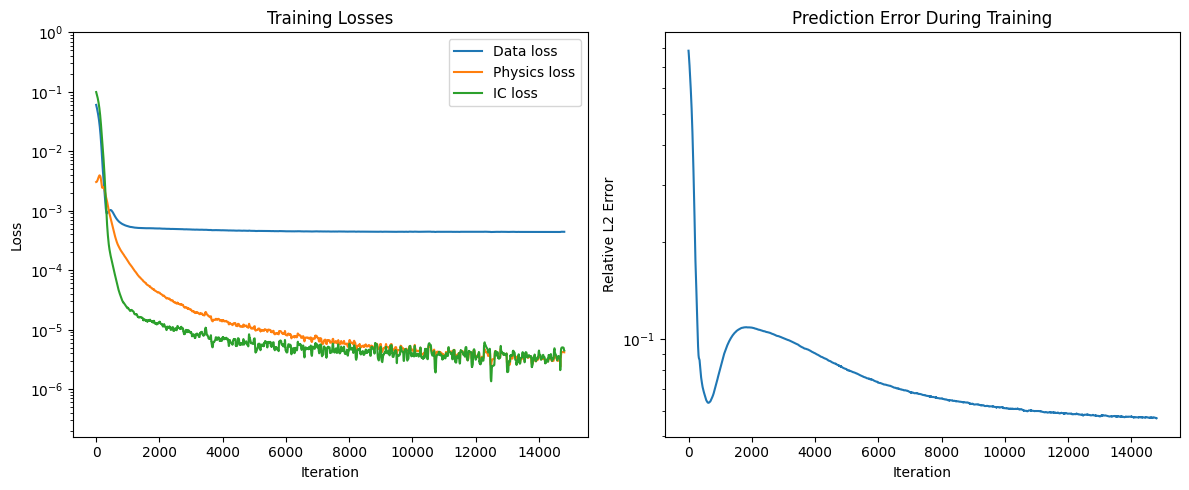

Relative L2 error on test grid: 4.10398e-02


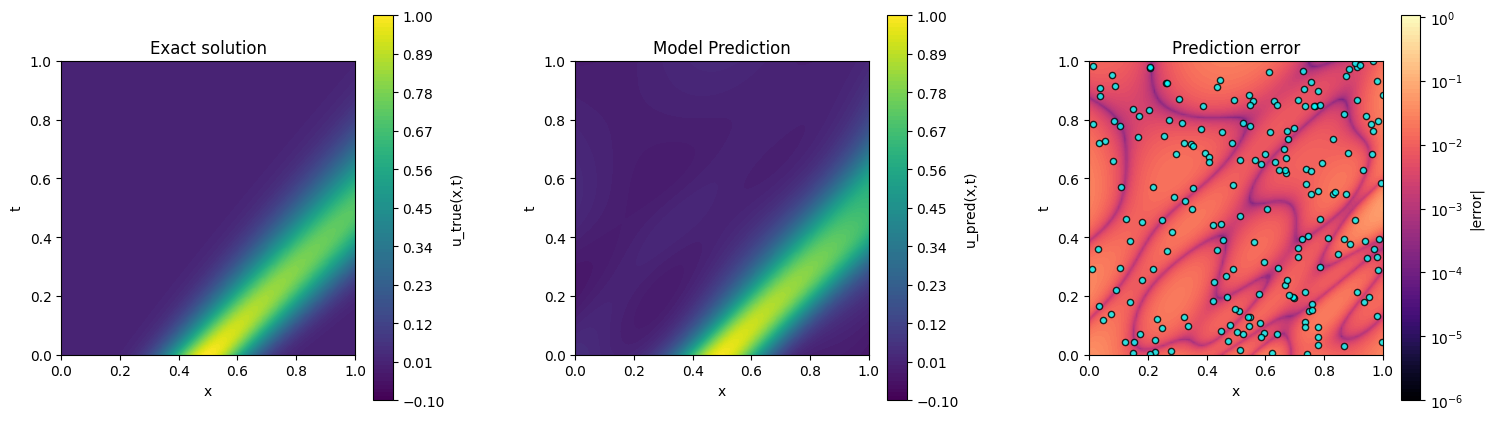

C:\Users\saulh\AppData\Local\Temp\ipykernel_6260\1101263514.py:116: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  levels = np.logspace(np.log10(1e-6), np.log10(res_limit), 100)


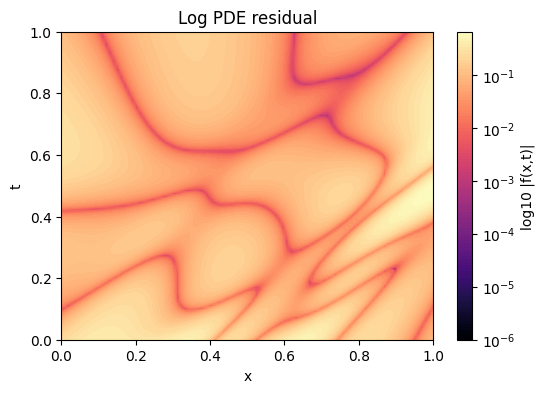

Average PDE residual on test grid: 1.43440e-01
Relative L2 error on test grid: 5.85973e-02


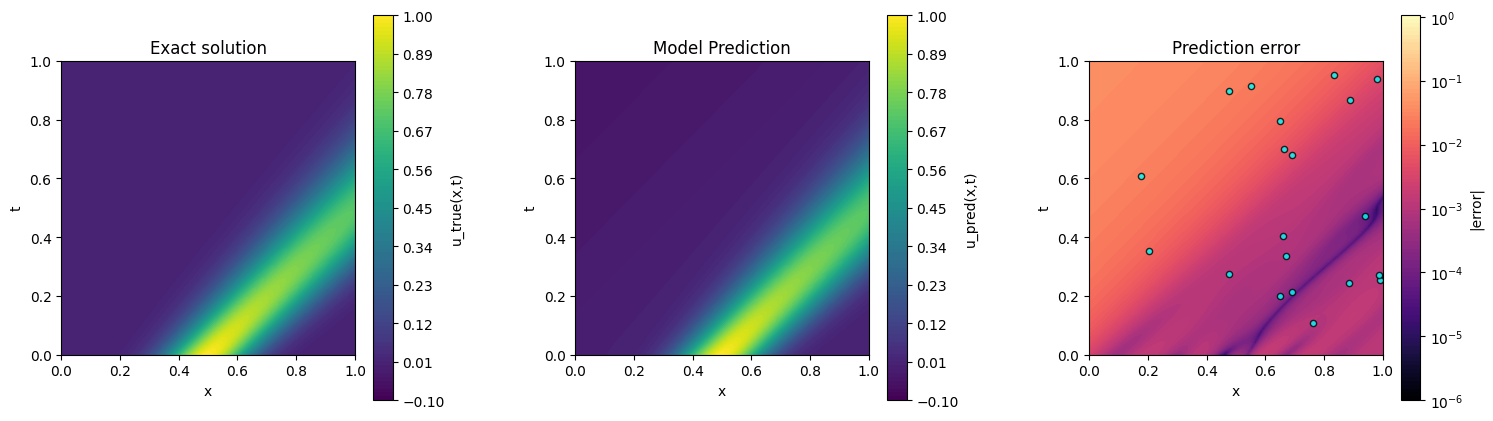

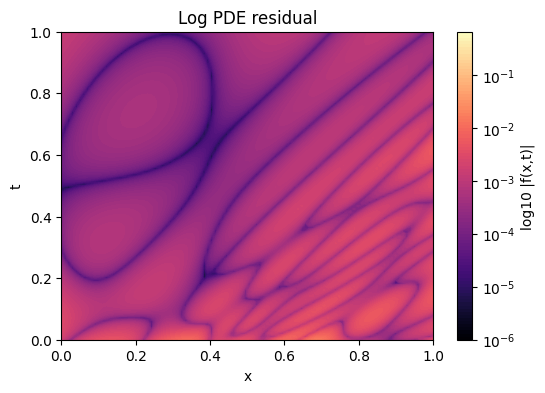

Average PDE residual on test grid: 1.24273e-03


In [48]:
# Compute relative max error for each dataset
# Convert tensors to numpy for linspace
err_max = max(max(loaded_nn_data.error), max(loaded_pinn_data.error))
err_max = np.round(err_max*10, 1) / 10.0  # rounds to nearest 0.1

err_min = min(min(loaded_nn_data.error), min(loaded_pinn_data.error))
err_min = min(err_min, 1e-6)  # avoid going below 1e-6 for log scale

res_nn = compute_pde_residual(loaded_nn_data, loaded_nn_model, loaded_nn_pde.c, loaded_nn_pde.D)
res_pinn = compute_pde_residual(loaded_pinn_data, loaded_pinn_model, loaded_pinn_pde.c, loaded_pinn_pde.D)

res_limit = max(res_nn.max(), res_pinn.max())

min_loss = min(min(loaded_nn_data.L_data), min(loaded_pinn_data.L_data), min(loaded_pinn_data.L_phys), min(loaded_pinn_data.L_ic))
max_loss = 1

plot_losses_and_error(
    loaded_nn_data.error,
    loaded_nn_data.L_data,
    loss_range=[min_loss, max_loss],
    window=200,
)

plot_losses_and_error(
    loaded_pinn_data.error,
    loaded_pinn_data.L_data,
    loaded_pinn_data.L_phys,
    loaded_pinn_data.L_ic,
    loss_range=[min_loss, max_loss],
    window=200
)

test_generalization(
    model=loaded_nn_model,
    data=loaded_nn_data,
    pde_params=loaded_nn_pde,
    residual=res_nn,
    test_points=100,  # adjust resolution if desired
    sol_limit=1.0,
    err_limit=[err_min, err_max],
    res_limit=res_limit
)

test_generalization(
    model=loaded_pinn_model,
    data=loaded_pinn_data,
    pde_params=loaded_pinn_pde,
    residual=res_pinn,
    test_points=100,  # adjust resolution if desired,
    sol_limit=1.0,
    err_limit=[err_min, err_max],
    res_limit=res_limit
)

